<a href="https://colab.research.google.com/github/CarolaineRangel/Visao-de-tempo-de-negociacao-x-Churn-e-faixa-de-faturamento/blob/main/Vis%C3%A3o_de_tempo_de_negocia%C3%A7%C3%A3o_x_Churn_e_faixa_de_faturamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
! pip install lifelines
!pip install kmodes
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

sns.set_style('darkgrid')

sheet_url = "https://docs.google.com/spreadsheets/d/1ZudmLpqAdtFCLfhtlgYgfbfeDXMw2S7WBCYw1YnFXHo/export?format=csv" ##sua base
df = pd.read_csv(sheet_url)

# Exibir as primeiras linhas do DataFrame para conferência
print(df.head())

    company_id              company_name  deal_id  idi_app  \
0  17326409869                   BBQ PUB      NaN  81272.0   
1  17326409870                    Barizz      NaN  80052.0   
2  17326409873  Cachorro Quente Original      NaN  84792.0   
3  17326409879            Adega Imperial      NaN  60913.0   
4  17326409880                 Burger 32      NaN  73165.0   

  company_lifecycle_stage  ativo last_won_date cohort_month won_month  \
0                     NaN      0    2023-08-10   2023-08-01   2023-08   
1                     NaN      0    2023-07-17   2023-07-01   2023-07   
2                customer      1    2023-08-29   2023-08-01   2023-08   
3                customer      1    2023-02-01   2023-02-01   2023-02   
4                     NaN      0    2023-05-23   2023-05-01   2023-05   

   cohort_early  ... has_issuer  has_zapturbo has_nitro has_greeting_message  \
0          2023  ...          0             0         0                    0   
1          2023  ...        

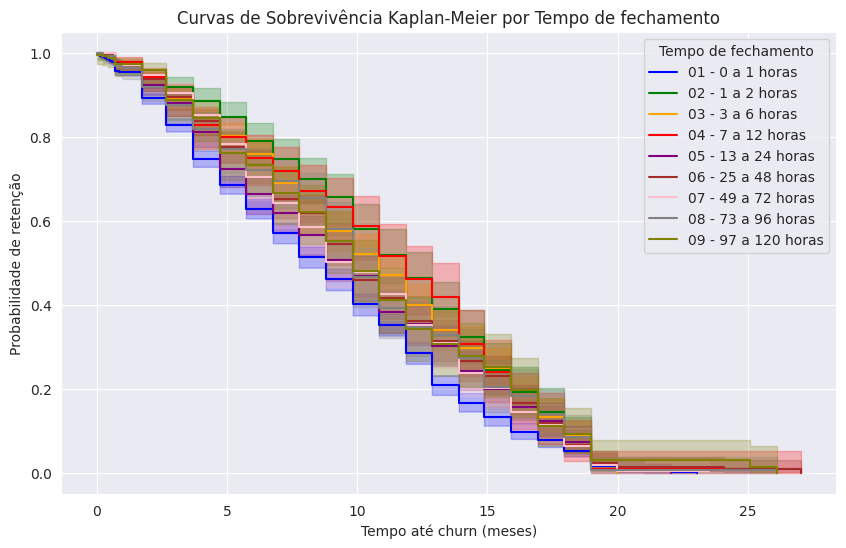

In [ ]:
# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["churn_date"].notna(),
    (df["churn_date"] - df["cohort_month"]).dt.days / 30,
    (df["current_date"] - df["cohort_month"]).dt.days / 30  # Clientes ainda ativos
)

# Filtrar apenas valores onde tempo_ate_churn >= 0
df = df[df["tempo_ate_churn"] >= 0]

# Remover valores NaN
df = df.dropna(subset=["tempo_ate_churn", "ativo", "category_time_for_hours"])


# Lista ordenada dos grupos por tempo
ordered_categories = [
    "01 - 0 a 1 horas",
    "02 - 1 a 2 horas",
    "03 - 3 a 6 horas",
    "04 - 7 a 12 horas",
    "05 - 13 a 24 horas",
    "06 - 25 a 48 horas",
    "07 - 49 a 72 horas",
    "08 - 73 a 96 horas",
    "09 - 97 a 120 horas",
    "10 - Mais de 120 horas"
]

# Ajustar o dicionário de cores (corrigido "02 - 1 a 2 horas'")
color_map = {
    "01 - 0 a 1 horas": "blue",
    "02 - 1 a 2 horas": "green",
    "03 - 3 a 6 horas": "orange",
    "04 - 7 a 12 horas": "red",
    "05 - 13 a 24 horas": "purple",
    "06 - 25 a 48 horas": "brown",
    "07 - 49 a 72 horas": "pink",
    "08 - 73 a 96 horas": "gray",
    "09 - 97 a 120 horas": "olive",
    "10 - Mais de 120 horas": "cyan"
}

plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()

# Gerar as curvas na ordem correta
for category in ordered_categories:
    if category in df["category_time_for_hours"].unique():
        mask = df["category_time_for_hours"] == category
        kmf.fit(
            df.loc[mask, "tempo_ate_churn"],
            event_observed=df.loc[mask, "ativo"],
            label=category
        )
        kmf.plot_survival_function(color=color_map.get(category, "gray"))

plt.title("Curvas de Sobrevivência Kaplan-Meier por Tempo até o fechamento da venda")
plt.xlabel("Tempo até churn (meses)")
plt.ylabel("Probabilidade de retenção")
plt.legend(title="Tempo de fechamento")
plt.grid(True)
plt.show()

In [ ]:
# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["churn_date"].notna(),
    (df["churn_date"] - df["cohort_month"]).dt.days / 30,
    (df["current_date"] - df["cohort_month"]).dt.days / 30  # Clientes ainda ativos
)

# Filtrar apenas valores onde tempo_ate_churn >= 0
df = df[df["tempo_ate_churn"] >= 0]

# Remover valores NaN
df = df.dropna(subset=["tempo_ate_churn", "ativo", "category_time_for_hours"])


# Lista ordenada dos grupos por tempo
ordered_categories = [
    "01 - 0 a 1 horas",
    "02 - 1 a 2 horas",
    "03 - 3 a 6 horas",
    "04 - 7 a 12 horas",
    "05 - 13 a 24 horas",
    "06 - 25 a 48 horas",
    "07 - 49 a 72 horas",
    "08 - 73 a 96 horas",
    "09 - 97 a 120 horas",
    "10 - Mais de 120 horas"
]

# Ajustar o dicionário de cores (corrigido "02 - 1 a 2 horas'")
color_map = {
    "01 - 0 a 1 horas": "blue",
    "02 - 1 a 2 horas": "green",
    "03 - 3 a 6 horas": "orange",
    "04 - 7 a 12 horas": "red",
    "05 - 13 a 24 horas": "purple",
    "06 - 25 a 48 horas": "brown",
    "07 - 49 a 72 horas": "pink",
    "08 - 73 a 96 horas": "gray",
    "09 - 97 a 120 horas": "olive",
    "10 - Mais de 120 horas": "cyan"
}

plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()

# Gerar as curvas na ordem correta
for category in ordered_categories:
    if category in df["category_time_for_hours"].unique():
        mask = df["category_time_for_hours"] == category
        kmf.fit(
            df.loc[mask, "tempo_ate_churn"],
            event_observed=df.loc[mask, "ativo"],
            label=category
        )
        kmf.plot_survival_function(color=color_map.get(category, "gray"))

plt.title("Curvas de Sobrevivência Kaplan-Meier por Tempo até o fechamento da venda")
plt.xlabel("Tempo até churn (meses)")
plt.ylabel("Probabilidade de retenção")
plt.legend(title="Tempo de fechamento")
plt.grid(True)
plt.show()

In [ ]:
from lifelines.statistics import pairwise_logrank_test

# Comparar todos os pares de categorias
results = pairwise_logrank_test(
    event_durations=df["tempo_ate_churn"],
    groups=df["category_time_for_hours"],
    event_observed=df["ativo"]
)

# Mostrar resultados
results.print_summary()


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
                                         test_statistic      p  -log2(p)
01 - 0 a 1 horas    02 - 1 a 2 horas              33.60 <0.005     27.14
                    03 - 3 a 6 horas              30.73 <0.005     25.01
                    04 - 7 a 12 horas             19.80 <0.005     16.83
                    05 - 13 a 24 horas             9.91 <0.005      9.25
                    06 - 25 a 48 horas            21.36 <0.005     18.00
                    07 - 49 a 72 horas            11.27 <0.005     10.31
                    08 - 73 a 96 horas            10.98 <0.005     10.09
                    09 - 97 a 120 horas           12.84 <0.005     11.52
                    10 - 120+ horas               12.18 <0.005     11.02
02 - 1 a 2 horas    03 - 3 a 6 horas               1.33   0.25      2.01
                    04 - 7 a 12 horas              0.31   0.58      0.78
                    05 - 13 a 24 horas             7.28   0.01      7.16
                    06 - 25 a 48 horas             3.71   0.05      4.21
                    07 - 49 a 72 horas             4.77   0.03      5.11
                    08 - 73 a 96 horas             2.89   0.09      3.48
                    09 - 97 a 120 horas            1.31   0.25      1.99
                    10 - 120+ horas               14.53 <0.005     12.83
03 - 3 a 6 horas    04 - 7 a 12 horas              0.16   0.69      0.54
                    05 - 13 a 24 horas             3.30   0.07      3.85
                    06 - 25 a 48 horas             0.74   0.39      1.36
                    07 - 49 a 72 horas             1.48   0.22      2.16
                    08 - 73 a 96 horas             0.62   0.43      1.21
                    09 - 97 a 120 horas            0.03   0.87      0.20
                    10 - 120+ horas                9.78 <0.005      9.15
04 - 7 a 12 horas   05 - 13 a 24 horas             3.66   0.06      4.16
                    06 - 25 a 48 horas             1.24   0.27      1.91
                    07 - 49 a 72 horas             1.90   0.17      2.57
                    08 - 73 a 96 horas             1.04   0.31      1.70
                    09 - 97 a 120 horas            0.44   0.51      0.98
                    10 - 120+ horas                7.49   0.01      7.33
05 - 13 a 24 horas  06 - 25 a 48 horas             1.13   0.29      1.80
                    07 - 49 a 72 horas             0.29   0.59      0.76
                    08 - 73 a 96 horas             0.65   0.42      1.25
                    09 - 97 a 120 horas            1.69   0.19      2.36
                    10 - 120+ horas                0.71   0.40      1.33
06 - 25 a 48 horas  07 - 49 a 72 horas             0.19   0.67      0.59
                    08 - 73 a 96 horas             0.00   0.96      0.06
                    09 - 97 a 120 horas            0.14   0.70      0.51
                    10 - 120+ horas                4.91   0.03      5.23
07 - 49 a 72 horas  08 - 73 a 96 horas             0.10   0.75      0.42
                    09 - 97 a 120 horas            0.54   0.46      1.11
                    10 - 120+ horas                1.65   0.20      2.33
08 - 73 a 96 horas  09 - 97 a 120 horas            0.12   0.73      0.45
                    10 - 120+ horas                2.63   0.10      3.25
09 - 97 a 120 horas 10 - 120+ horas                4.11   0.04      4.56

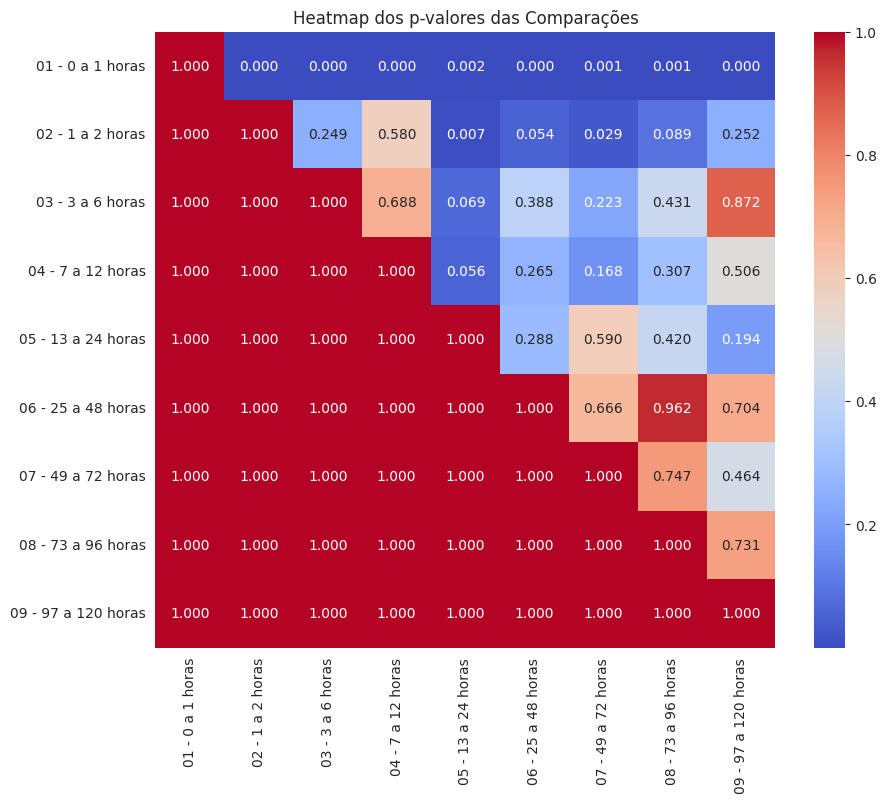

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Acessando os p-valores da tabela summary
p_values = results.summary['p']

# Extraindo os grupos para serem usados como rótulos de linha e coluna
group_labels = p_values.index.get_level_values(0).unique()

# Criando uma matriz de p-valores
p_values_matrix = pd.DataFrame(index=group_labels, columns=group_labels, dtype=float)

# Preenchendo a matriz de p-valores
for group_1 in group_labels:
    for group_2 in group_labels:
        try:
            # Encontrar o p-valor para cada par de grupos
            p_value = p_values.loc[(group_1, group_2)]  # Corrigido para multi-índice
        except KeyError:
            p_value = 1.0  # Caso não exista uma comparação, definir como 1.0
        p_values_matrix.loc[group_1, group_2] = p_value

# Gerar o heatmap com a matriz de p-valores
plt.figure(figsize=(10, 8))
sns.heatmap(p_values_matrix.astype(float), annot=True, cmap="coolwarm", fmt=".3f", cbar=True)
plt.title("Heatmap dos p-valores das Comparações")
plt.show()


<ipython-input-30-345472cd1277>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tempo_ate_churn"] = np.where(


Total de clientes considerados: 4438


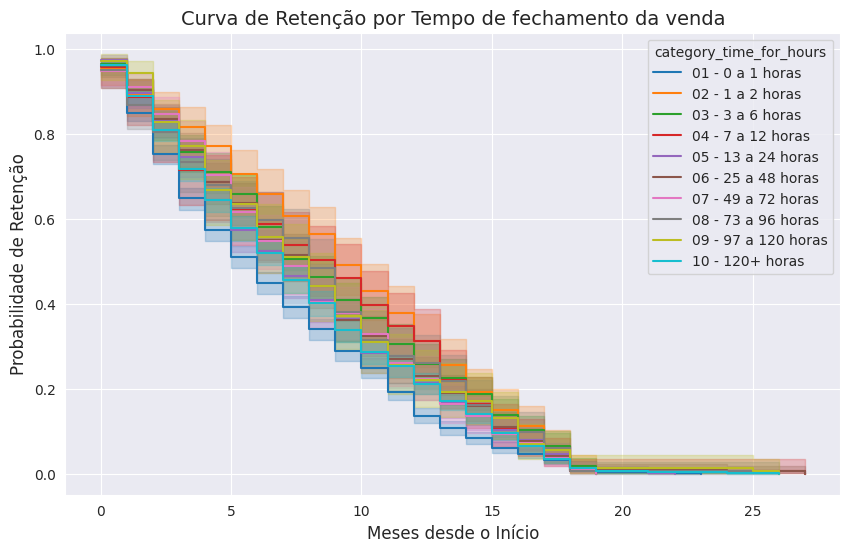

In [ ]:
# Converter churn_date e cohort_month para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()  # Apenas data, sem horário

# Garantir que não há valores NaN em company_lifecycle_stage
df = df.dropna(subset=["company_lifecycle_stage"])

# Aplicar a lógica para calcular tempo_ate_churn corretamente
df["tempo_ate_churn"] = np.where(
    df["company_lifecycle_stage"] == "customer",
    (df["current_date"] - df["cohort_month"]).dt.days / 30,  # Tempo até hoje (em meses)
    np.where(
        df["churn_date"].notna(),  # Verifica se churn_date não é NaN
        (df["churn_date"] - df["cohort_month"]).dt.days / 30,  # Tempo até churn (em meses)
        np.nan  # Se churn_date for NaN, deixa NaN
    )
)

# Remover valores NaN antes do modelo
df_kmf = df.dropna(subset=["tempo_ate_churn", "ativo"]).copy()

# Garantir que os tipos de dados estão corretos
df_kmf["tempo_ate_churn"] = df_kmf["tempo_ate_churn"].astype(int)  # Transformar em inteiro
df_kmf["ativo"] = df_kmf["ativo"].astype(int)  # Garantir que é 0 ou 1

# Filtrar para considerar apenas tempos positivos ou zero
df_kmf = df_kmf[df_kmf["tempo_ate_churn"] >= 0]

# Verificar se há dados suficientes antes de rodar o modelo
print(f"Total de clientes considerados: {len(df_kmf)}")

if len(df_kmf) > 0:
    plt.figure(figsize=(10, 6))

    # Criar e ajustar um modelo Kaplan-Meier para cada document_type
    for doc_type, df_group in df_kmf.groupby("category_time_for_hours"):
        kmf = KaplanMeierFitter()
        kmf.fit(df_group["tempo_ate_churn"], event_observed=df_group["ativo"], label=f"{doc_type}")

        # Plotar a curva de retenção para cada document_type
        kmf.plot_survival_function()

    # Ajustar rótulos e título
    plt.title("Curva de Retenção por Tempo de fechamento da venda", fontsize=14)
    plt.xlabel("Meses desde o Início", fontsize=12)
    plt.ylabel("Probabilidade de Retenção", fontsize=12)

    # Adicionar legenda para identificar os diferentes tipos de documentos
    plt.legend(title="category_time_for_hours", fontsize=10)

    # Definir rótulos no eixo X a cada 5 meses
    max_x = df_kmf["tempo_ate_churn"].max()
    if max_x > 0:
        plt.xticks(np.arange(0, max_x + 1, step=5))

    plt.show()
else:
    print("Erro: Nenhum dado disponível para análise.")

<lifelines.CoxPHFitter: fitted with 6838 total observations, 3224 right-censored observations>
             duration col = 'tempo_ate_churn'
                event col = 'ativo'
      baseline estimation = breslow
   number of observations = 6838
number of events observed = 3614
   partial log-likelihood = -26877.20
         time fit was run = 2025-04-22 17:01:10 UTC

---
                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                    
category_time_for_hours_01 - 0 a 1 horas     0.27      1.31      0.05            0.18            0.37                1.19                1.45
category_time_for_hours_02 - 1 a 2 horas    -0.16      0.86      0.08           -0.31           -0.00                0.73                1.00
category_time_for_hours_03 - 3 a 6 horas    -0.12      0.89      0.07           -0.25            0.01                0.78                1.01
category_time_for_hours_04 - 7 a 12 horas   -0.11      0.90      0.09           -0.29            0.08                0.74                1.08
category_time_for_hours_05 - 13 a 24 horas  -0.03      0.98      0.07           -0.16            0.11                0.85                1.11
category_time_for_hours_06 - 25 a 48 horas  -0.07      0.93      0.07           -0.20            0.06                0.82                1.06
category_time_for_hours_07 - 49 a 72 horas  -0.02      0.98      0.08           -0.17            0.14                0.84                1.15
category_time_for_hours_08 - 73 a 96 horas  -0.06      0.94      0.09           -0.23            0.11                0.80                1.12
category_time_for_hours_09 - 97 a 120 horas -0.04      0.96      0.10           -0.23            0.15                0.80                1.17

                                             cmp to     z      p  -log2(p)
covariate                                                                 
category_time_for_hours_01 - 0 a 1 horas       0.00  5.61 <0.005     25.59
category_time_for_hours_02 - 1 a 2 horas       0.00 -1.97   0.05      4.35
category_time_for_hours_03 - 3 a 6 horas       0.00 -1.85   0.06      3.95
category_time_for_hours_04 - 7 a 12 horas      0.00 -1.15   0.25      2.00
category_time_for_hours_05 - 13 a 24 horas     0.00 -0.37   0.71      0.49
category_time_for_hours_06 - 25 a 48 horas     0.00 -1.03   0.30      1.72
category_time_for_hours_07 - 49 a 72 horas     0.00 -0.21   0.84      0.26
category_time_for_hours_08 - 73 a 96 horas     0.00 -0.67   0.50      0.99
category_time_for_hours_09 - 97 a 120 horas    0.00 -0.38   0.70      0.51
---
Concordance = 0.56
Partial AIC = 53772.41
log-likelihood ratio test = 84.56 on 9 df
-log2(p) of ll-ratio test = 45.51

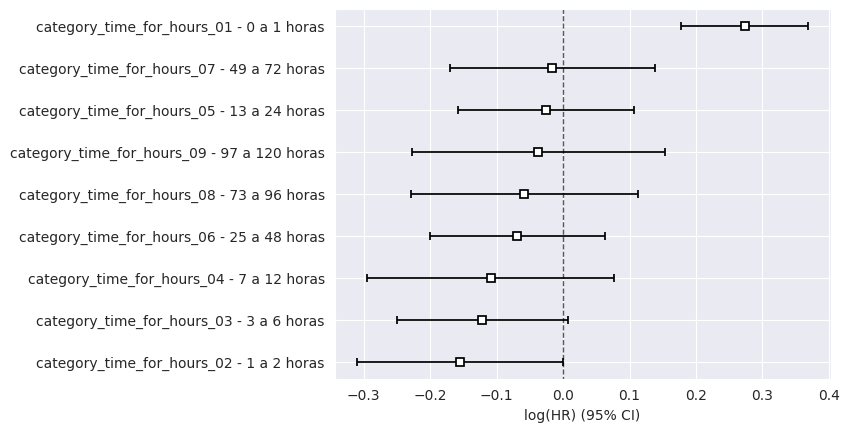

In [ ]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# Carregar os dados da planilha do Google
sheet_url = "https://docs.google.com/spreadsheets/d/1ZudmLpqAdtFCLfhtlgYgfbfeDXMw2S7WBCYw1YnFXHo/export?format=csv"
df = pd.read_csv(sheet_url)

# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["company_lifecycle_stage"] == "customer",
    (df["current_date"] - df["cohort_month"]).dt.days / 30,
    np.where(
        df["churn_date"].notna(),
        (df["churn_date"] - df["cohort_month"]).dt.days / 30,
        np.nan
    )
)

# Remover valores NaN nas variáveis relevantes
df = df.dropna(subset=["tempo_ate_churn", "ativo"] + [col for col in df.columns if col.startswith("category_time_for_hours")])

# Converter variável categórica para dummies
df = pd.get_dummies(df, columns=["category_time_for_hours"], drop_first=False)

# Renomear as colunas de forma correta
df.rename(columns={
   "category_time_for_hours_01": "01 - 0 a 1 horas",
   "category_time_for_hours_02": "02 - 1 a 2 horas",
   "category_time_for_hours_03": "03 - 3 a 6 horas",
   "category_time_for_hours_04": "04 - 7 a 12 horas",
   "category_time_for_hours_05": "05 - 13 a 24 horas",
   "category_time_for_hours_06": "06 - 25 a 48 horas",
   "category_time_for_hours_07": "07 - 49 a 72 horas",
   "category_time_for_hours_08": "08 - 73 a 96 horas",
   "category_time_for_hours_09": "09 - 97 a 120 horas",
   "category_time_for_hours_10": "10 - Mais de 120 horas"
}, inplace=True)


df.drop(columns=["category_time_for_hours_10 - 120+ horas"], inplace=True) # Remover a coluna que corresponde à faixa "0 a 1 horas"

# Criar modelo de Cox
cph = CoxPHFitter()
cph.fit(df[[
    "tempo_ate_churn", "ativo", "category_time_for_hours_01 - 0 a 1 horas", "category_time_for_hours_02 - 1 a 2 horas", "category_time_for_hours_03 - 3 a 6 horas",
    "category_time_for_hours_04 - 7 a 12 horas", "category_time_for_hours_05 - 13 a 24 horas", "category_time_for_hours_06 - 25 a 48 horas",
    "category_time_for_hours_07 - 49 a 72 horas", "category_time_for_hours_08 - 73 a 96 horas", "category_time_for_hours_09 - 97 a 120 horas"

]], duration_col="tempo_ate_churn", event_col="ativo")

# Exibir resultados com duas casas decimais
cph.print_summary(decimals=2)

# Plotar coeficientes do modelo
cph.plot()
plt.show()


<lifelines.CoxPHFitter: fitted with 6838 total observations, 3224 right-censored observations>
             duration col = 'tempo_ate_churn'
                event col = 'ativo'
      baseline estimation = breslow
   number of observations = 6838
number of events observed = 3614
   partial log-likelihood = -26877.20
         time fit was run = 2025-04-22 17:16:48 UTC

---
                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                    
category_time_for_hours_02 - 1 a 2 horas    -0.43      0.65      0.08           -0.58           -0.28                0.56                0.76
category_time_for_hours_03 - 3 a 6 horas    -0.39      0.67      0.06           -0.52           -0.27                0.60                0.76
category_time_for_hours_04 - 7 a 12 horas   -0.38      0.68      0.09           -0.56           -0.20                0.57                0.82
category_time_for_hours_05 - 13 a 24 horas  -0.30      0.74      0.06           -0.42           -0.17                0.65                0.84
category_time_for_hours_06 - 25 a 48 horas  -0.34      0.71      0.06           -0.47           -0.22                0.63                0.80
category_time_for_hours_07 - 49 a 72 horas  -0.29      0.75      0.08           -0.44           -0.14                0.65                0.87
category_time_for_hours_08 - 73 a 96 horas  -0.33      0.72      0.08           -0.50           -0.17                0.61                0.85
category_time_for_hours_09 - 97 a 120 horas -0.31      0.73      0.09           -0.50           -0.13                0.61                0.88
category_time_for_hours_10 - 120+ horas     -0.27      0.76      0.05           -0.37           -0.18                0.69                0.84

                                             cmp to     z      p  -log2(p)
covariate                                                                 
category_time_for_hours_02 - 1 a 2 horas       0.00 -5.66 <0.005     26.01
category_time_for_hours_03 - 3 a 6 horas       0.00 -6.39 <0.005     32.48
category_time_for_hours_04 - 7 a 12 horas      0.00 -4.16 <0.005     14.91
category_time_for_hours_05 - 13 a 24 horas     0.00 -4.68 <0.005     18.41
category_time_for_hours_06 - 25 a 48 horas     0.00 -5.41 <0.005     23.90
category_time_for_hours_07 - 49 a 72 horas     0.00 -3.84 <0.005     12.96
category_time_for_hours_08 - 73 a 96 horas     0.00 -3.94 <0.005     13.57
category_time_for_hours_09 - 97 a 120 horas    0.00 -3.28 <0.005      9.93
category_time_for_hours_10 - 120+ horas        0.00 -5.61 <0.005     25.59
---
Concordance = 0.56
Partial AIC = 53772.41
log-likelihood ratio test = 84.56 on 9 df
-log2(p) of ll-ratio test = 45.51

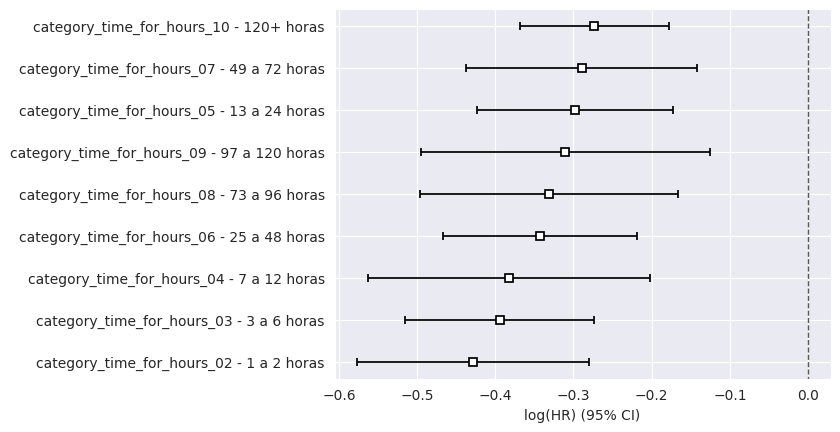

In [ ]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# Carregar os dados da planilha do Google
sheet_url = "https://docs.google.com/spreadsheets/d/1ZudmLpqAdtFCLfhtlgYgfbfeDXMw2S7WBCYw1YnFXHo/export?format=csv"
df = pd.read_csv(sheet_url)

# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["company_lifecycle_stage"] == "customer",
    (df["current_date"] - df["cohort_month"]).dt.days / 30,
    np.where(
        df["churn_date"].notna(),
        (df["churn_date"] - df["cohort_month"]).dt.days / 30,
        np.nan
    )
)

# Remover valores NaN nas variáveis relevantes
df = df.dropna(subset=["tempo_ate_churn", "ativo"] + [col for col in df.columns if col.startswith("category_time_for_hours")])

# Converter variável categórica para dummies
df = pd.get_dummies(df, columns=["category_time_for_hours"], drop_first=False)

# Renomear as colunas de forma correta
df.rename(columns={
   "category_time_for_hours_01": "01 - 0 a 1 horas",
   "category_time_for_hours_02": "02 - 1 a 2 horas",
   "category_time_for_hours_03": "03 - 3 a 6 horas",
   "category_time_for_hours_04": "04 - 7 a 12 horas",
   "category_time_for_hours_05": "05 - 13 a 24 horas",
   "category_time_for_hours_06": "06 - 25 a 48 horas",
   "category_time_for_hours_07": "07 - 49 a 72 horas",
   "category_time_for_hours_08": "08 - 73 a 96 horas",
   "category_time_for_hours_09": "09 - 97 a 120 horas",
   "category_time_for_hours_10": "10 - Mais de 120 horas"
}, inplace=True)


df.drop(columns=["category_time_for_hours_01 - 0 a 1 horas"], inplace=True) # Remover a coluna que corresponde à faixa "0 a 1 horas"

# Criar modelo de Cox
cph = CoxPHFitter()
cph.fit(df[[
    "tempo_ate_churn", "ativo", "category_time_for_hours_02 - 1 a 2 horas", "category_time_for_hours_03 - 3 a 6 horas",
    "category_time_for_hours_04 - 7 a 12 horas", "category_time_for_hours_05 - 13 a 24 horas", "category_time_for_hours_06 - 25 a 48 horas",
    "category_time_for_hours_07 - 49 a 72 horas", "category_time_for_hours_08 - 73 a 96 horas", "category_time_for_hours_09 - 97 a 120 horas", "category_time_for_hours_10 - 120+ horas"

]], duration_col="tempo_ate_churn", event_col="ativo")

# Exibir resultados com duas casas decimais
cph.print_summary(decimals=2)

# Plotar coeficientes do modelo
cph.plot()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

sheet_url = "https://docs.google.com/spreadsheets/d/1ZudmLpqAdtFCLfhtlgYgfbfeDXMw2S7WBCYw1YnFXHo/export?format=csv"
df = pd.read_csv(sheet_url)
# Supondo que df seja o DataFrame retornado do BigQuery
# Primeiro, armazene a coluna 'company_id' em uma variável separada
company_ids = df['company_id'].copy()

# Crie uma cópia do DataFrame para processar a clusterização
df_cluster = df.copy()

# Remova a coluna 'company_id' de df_cluster para não interferir na clusterização
df_cluster.drop(columns=['company_id'], inplace=True, errors='ignore')

# --- Pré-processamento ---
# Corrige vírgulas e tenta converter para float (quando aplicável)
for col in df_cluster.columns:
    if df_cluster[col].dtype == 'object':
        try:
            df_cluster[col] = df_cluster[col].str.replace(',', '.').astype(float)
        except:
            continue

# Identifica colunas categóricas e preenche NaNs com "desconhecido"
categorical_cols = []
for i, col in enumerate(df_cluster.columns):
    if df_cluster[col].dtype == 'object' or df_cluster[col].dtype == bool:
        categorical_cols.append(i)
        df_cluster[col] = df_cluster[col].astype(str).fillna("desconhecido")

# Preenche colunas numéricas com a média (se houver NaNs)
for col in df_cluster.columns:
    if df_cluster[col].dtype in [np.float64, np.int64]:
        df_cluster[col] = df_cluster[col].fillna(df_cluster[col].mean())

# Verifica se não há mais NaNs
assert df_cluster.isna().sum().sum() == 0, "Ainda há valores NaN no df_cluster!"

# --- Clusterização com K-Prototypes ---
# Converte para array (todos os dados de df_cluster, que agora NÃO contém company_id)
matrix = df_cluster.to_numpy()

# Aplica o K-Prototypes
kproto = KPrototypes(n_clusters=2, init='Cao', n_init=1, verbose=1, gamma=0)
clusters = kproto.fit_predict(matrix, categorical=categorical_cols)

# --- Reassocia os clusters ao DataFrame original ---
df['Cluster'] = clusters
# Reinsere a coluna 'company_id' usando a variável armazenada
df['company_id'] = company_ids

# --- Cria tabela com company_id e Cluster ---
tabela_cluster_por_empresa = df[['company_id', 'Cluster']].copy()
print("\n🔍 Tabela com company_id e Cluster:")
print(tabela_cluster_por_empresa.head())

pd.set_option('display.max_rows', None)
file_path = 'tabela_cluster_por_empresa.xlsx'
tabela_cluster_por_empresa.to_excel(file_path, index=False)

# Se estiver no Google Colab, usa este para baixar:
#from google.colab import files
#files.download(file_path)


Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 0, ncost: 8.153198776620773e+22

🔍 Tabela com company_id e Cluster:
    company_id  Cluster
0  17326409869        1
1  17326409870        1
2  17326409873        1
3  17326409879        1
4  17326409880        1


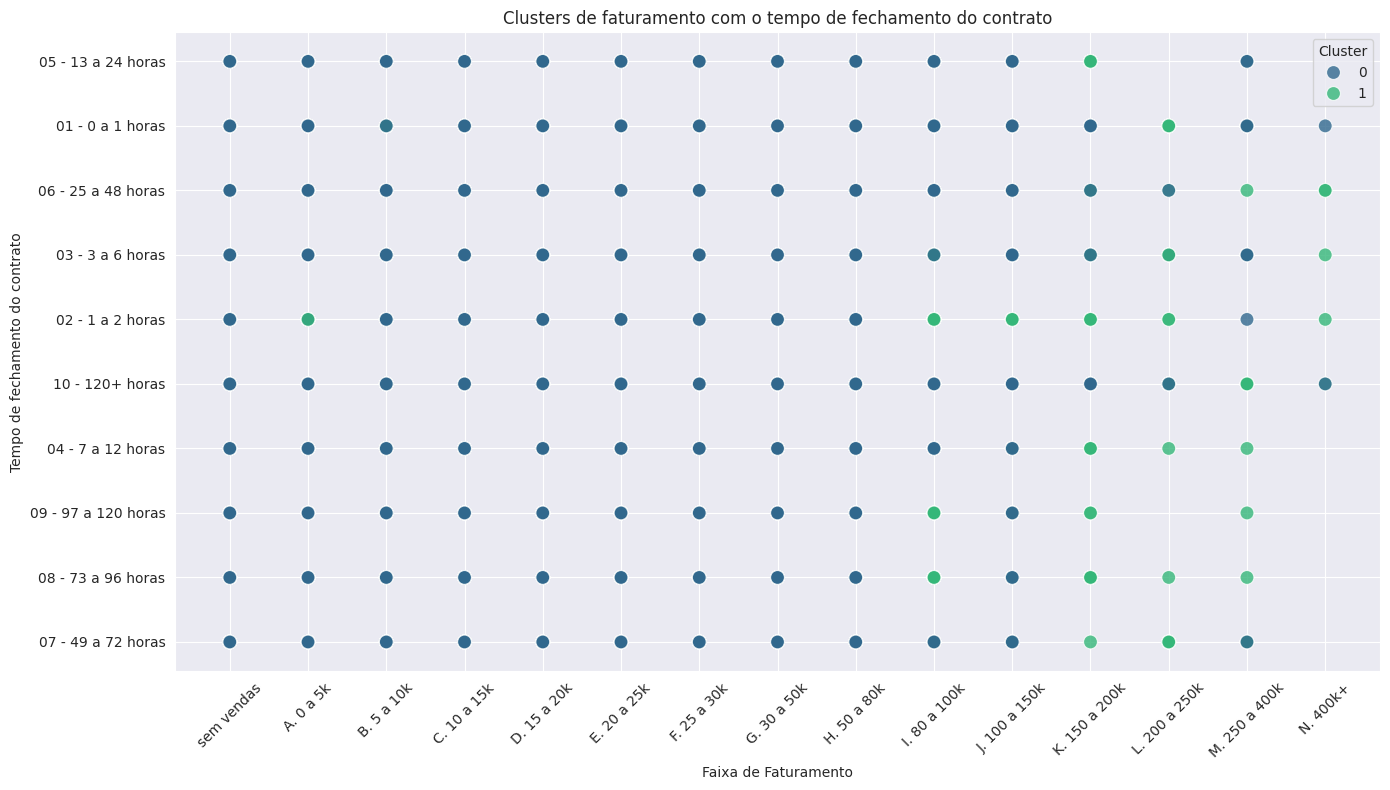

In [ ]:

ordem_faixas = [
    'sem vendas',
    'A. 0 a 5k', 'B. 5 a 10k', 'C. 10 a 15k', 'D. 15 a 20k', 'E. 20 a 25k',
    'F. 25 a 30k', 'G. 30 a 50k', 'H. 50 a 80k', 'I. 80 a 100k',
    'J. 100 a 150k', 'K. 150 a 200k', 'L. 200 a 250k', 'M. 250 a 400k', 'N. 400k+'
]

# Convertendo para tipo categórico ordenado
df['faixa_faturamento'] = pd.Categorical(df['faixa_faturamento'], categories=ordem_faixas, ordered=True)

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df,
    x= 'faixa_faturamento',
    y='category_time_for_hours'  ,
    hue='Cluster',
    palette='viridis',
    alpha=0.8,
    s=100
)
plt.title('Clusters de faturamento com o tempo de fechamento do contrato')
plt.xlabel('Faixa de Faturamento' )
plt.ylabel('Tempo de fechamento do contrato')
plt.xticks(rotation=45)
#plt.ylim(0, 100)  # Força o limite superior para 100 meses
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from lifelines import KaplanMeierFitter
import numpy as np

# Importando o CSV diretamente da URL
sheet_url = "https://docs.google.com/spreadsheets/d/1ZudmLpqAdtFCLfhtlgYgfbfeDXMw2S7WBCYw1YnFXHo/export?format=csv"
df = pd.read_csv(sheet_url)

# Remover valores NaN nas variáveis relevantes antes de qualquer outra transformação
df = df.dropna(subset=["ativo", "category_time_for_hours"])

# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["company_lifecycle_stage"] == "customer",
    (df["current_date"] - df["cohort_month"]).dt.days / 30,
    np.where(
        df["churn_date"].notna(),
        (df["churn_date"] - df["cohort_month"]).dt.days / 30,
        np.nan
    )
)

# Mapeando as categorias de tempo para valores numéricos representando a média de horas
category_time_mapping = {
    "01 - 0 a 1 horas": 0.5,
    "02 - 1 a 2 horas": 1.5,
    "03 - 3 a 6 horas": 4.5,
    "04 - 7 a 12 horas": 9.5,
    "05 - 13 a 24 horas": 18.5,
    "06 - 25 a 48 horas": 36.5,
    "07 - 49 a 72 horas": 60.5,
    "08 - 73 a 96 horas": 84.5,
    "09 - 97 a 120 horas": 108.5,
    "10 - Mais de 120 horas": 130
}

# Aplicando a transformação para criar uma coluna numérica de tempo
df['category_time_for_hours_numeric'] = df['category_time_for_hours'].map(category_time_mapping)

# Verificar se há valores NaN após a transformação
df = df.dropna(subset=["category_time_for_hours_numeric"])

# Inicializando o modelo Kaplan-Meier
kmf = KaplanMeierFitter()

# Inicializando um dicionário para armazenar as taxas de sobrevivência por combinação
survival_matrix = {}

# Calculando a sobrevivência para cada combinação de faixa de faturamento e tempo de fechamento
for faturamento in df['faixa_faturamento'].unique():
    for tempo in df['category_time_for_hours'].unique():
        # Filtrando os dados para cada combinação
        subset = df[(df['faixa_faturamento'] == faturamento) & (df['category_time_for_hours'] == tempo)]

        # Verificando se a combinação possui dados suficientes
        if len(subset) > 0:
            # Ajustando o modelo Kaplan-Meier para a combinação filtrada
            kmf.fit(subset['category_time_for_hours_numeric'], event_observed=subset['ativo'])

            # Armazenando a sobrevivência média no dicionário
            survival_matrix[(faturamento, tempo)] = kmf.survival_function_.iloc[-1, 0]  # Última sobrevivência

# Convertendo o dicionário para um DataFrame para facilitar a visualização
survival_df = pd.DataFrame.from_dict(survival_matrix, orient='index', columns=['Sobrevivência'])
survival_df.index = pd.MultiIndex.from_tuples(survival_df.index, names=['Faixa de Faturamento', 'Tempo de Fechamento'])
survival_df = survival_df.unstack(level=0).T

# Exibindo a matriz de sobrevivência
print(survival_df)


Tempo de Fechamento                 01 - 0 a 1 horas  02 - 1 a 2 horas  \
              Faixa de Faturamento                                       
Sobrevivência A. 0 a 5k                     0.608456          0.663265   
              B. 5 a 10k                    0.410909          0.500000   
              C. 10 a 15k                   0.312500          0.363636   
              D. 15 a 20k                   0.295000          0.500000   
              E. 20 a 25k                   0.274510          0.136364   
              F. 25 a 30k                   0.237410          0.363636   
              G. 30 a 50k                   0.207207          0.176471   
              H. 50 a 80k                   0.141509          0.058824   
              I. 80 a 100k                  0.095890          0.000000   
              J. 100 a 150k                 0.104478          0.000000   
              K. 150 a 200k                 0.000000          0.250000   
              L. 200 a 250k           

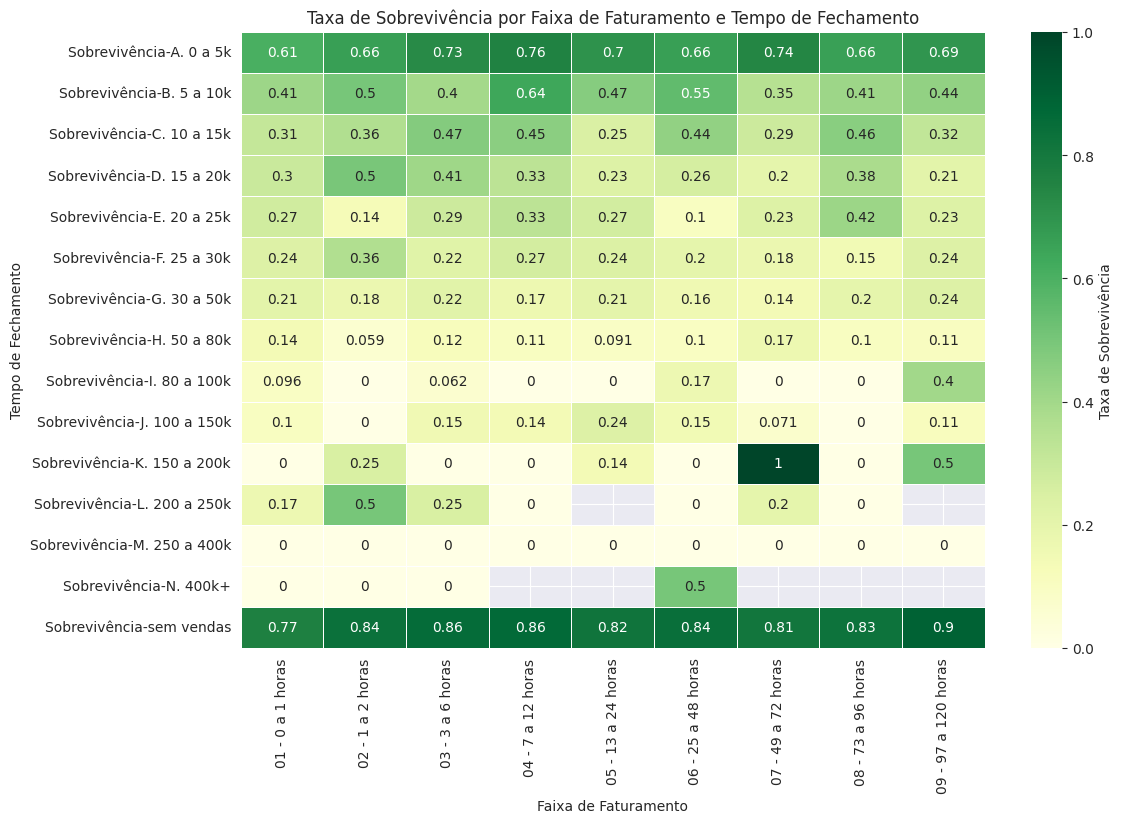

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo o tamanho da figura para o gráfico
plt.figure(figsize=(12, 8))

# Criando o heatmap
sns.heatmap(survival_df, annot=True, cmap="YlGn", cbar_kws={'label': 'Taxa de Sobrevivência'}, linewidths=0.5)

# Adicionando título e labels
plt.title("Taxa de Sobrevivência por Faixa de Faturamento e Tempo de Fechamento")
plt.xlabel("Faixa de Faturamento")
plt.ylabel("Tempo de Fechamento")

# Exibindo o gráfico
plt.show()

Tempo de Fechamento                             01 - 0 a 1 horas  \
                          Faixa de Faturamento                     
Sobrevivência aos 6 meses A. 0 a 5k                     0.540014   
                          B. 5 a 10k                    0.536939   
                          C. 10 a 15k                   0.548688   
                          D. 15 a 20k                   0.558734   
                          E. 20 a 25k                   0.550711   
                          F. 25 a 30k                   0.654377   
                          G. 30 a 50k                   0.663421   
                          H. 50 a 80k                   0.657094   
                          I. 80 a 100k                  0.777778   
                          J. 100 a 150k                 0.671919   
                          K. 150 a 200k                 0.588235   
                          L. 200 a 250k                 1.000000   
                          M. 250 a 400k         

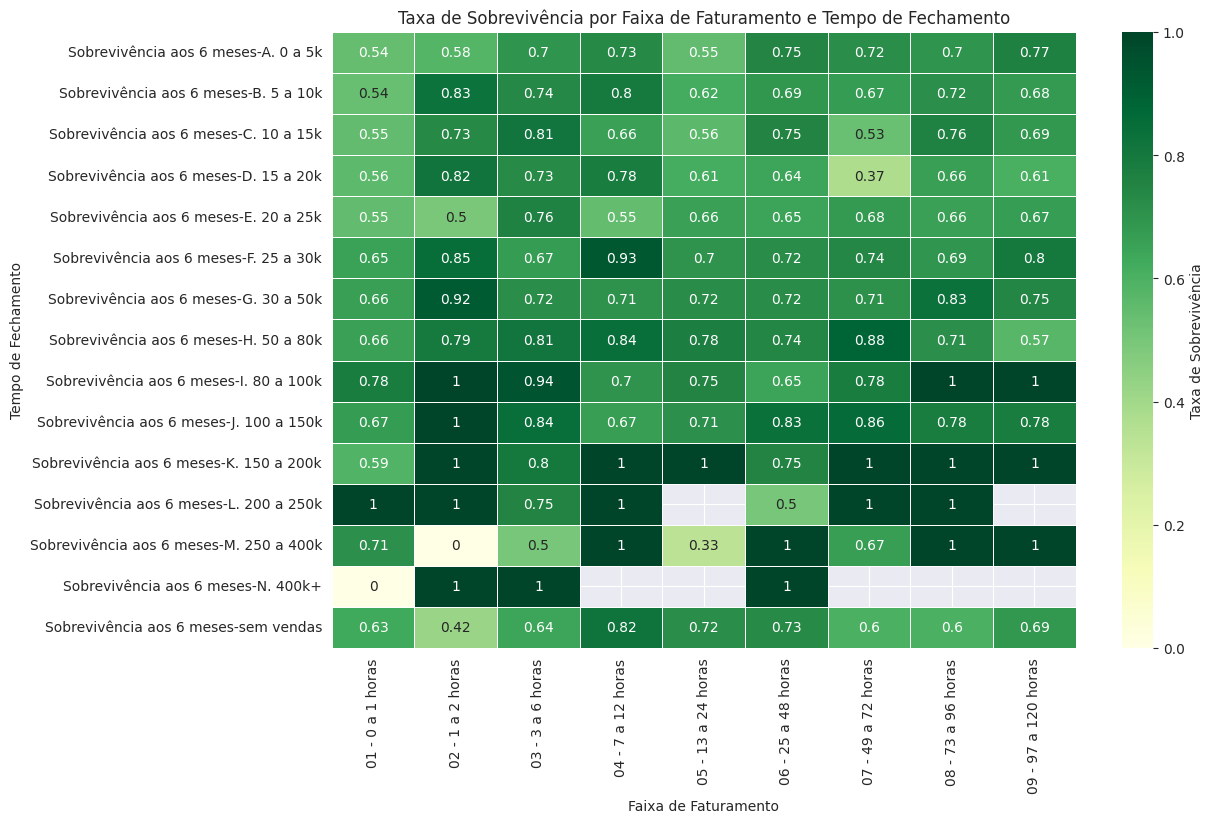

In [ ]:
import pandas as pd
from lifelines import KaplanMeierFitter
import numpy as np

# Importando o CSV diretamente da URL
sheet_url = "https://docs.google.com/spreadsheets/d/1ZudmLpqAdtFCLfhtlgYgfbfeDXMw2S7WBCYw1YnFXHo/export?format=csv"
df = pd.read_csv(sheet_url)


# Converter datas para datetime
df["last_won_date"] = pd.to_datetime(df["last_won_date"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_de_vida_em_dias"] = np.where(
    df["company_lifecycle_stage"] == "customer",
    (df["current_date"] - df["last_won_date"]).dt.days ,
    np.where(
        df["churn_date"].notna(),
        (df["churn_date"] - df["last_won_date"]).dt.days,
        np.nan
    )
)
#df.head(10)

# Remover valores NaN nas variáveis relevantes antes de qualquer outra transformação
df = df.dropna(subset=["ativo", "category_time_for_hours", "tempo_de_vida_em_dias"])

# Mapeando as categorias de tempo para valores numéricos representando a média de horas
category_time_mapping = {
    "01 - 0 a 1 horas": 0.5,
    "02 - 1 a 2 horas": 1.5,
    "03 - 3 a 6 horas": 4.5,
    "04 - 7 a 12 horas": 9.5,
    "05 - 13 a 24 horas": 18.5,
    "06 - 25 a 48 horas": 36.5,
    "07 - 49 a 72 horas": 60.5,
    "08 - 73 a 96 horas": 84.5,
    "09 - 97 a 120 horas": 108.5,
    "10 - Mais de 120 horas": 130
}

# Aplicando a transformação para criar uma coluna numérica de tempo
df['category_time_for_hours_numeric'] = df['category_time_for_hours'].map(category_time_mapping)

# Verificar se há valores NaN após a transformação
df = df.dropna(subset=["category_time_for_hours_numeric"])

# Inicializando o KM
kmf = KaplanMeierFitter()

# Dicionário para armazenar a sobrevivência estimada em 180 dias (6 meses)
survival_matrix = {}

# Para cada combinação de tempo de fechamento e faixa de faturamento
for faturamento in df['faixa_faturamento'].unique():
    for tempo in df['category_time_for_hours'].unique():
        subset = df[(df['faixa_faturamento'] == faturamento) &
                    (df['category_time_for_hours'] == tempo)]

        if len(subset) > 0:
            kmf.fit(subset['tempo_de_vida_em_dias'], event_observed=subset['ativo'])

            # Pegando a sobrevivência aos 180 dias (6 meses)
            prob_6_meses = kmf.predict(180)
            survival_matrix[(faturamento, tempo)] = prob_6_meses

# Convertendo em DataFrame
survival_df = pd.DataFrame.from_dict(survival_matrix, orient='index', columns=['Sobrevivência aos 6 meses'])
survival_df.index = pd.MultiIndex.from_tuples(survival_df.index, names=['Faixa de Faturamento', 'Tempo de Fechamento'])
survival_df = survival_df.unstack(level=0).T

# Exibindo
print(survival_df)
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo o tamanho da figura para o gráfico
plt.figure(figsize=(12, 8))

# Criando o heatmap
sns.heatmap(survival_df, annot=True, cmap="YlGn", cbar_kws={'label': 'Taxa de Sobrevivência'}, linewidths=0.5)

# Adicionando título e labels
plt.title("Taxa de Sobrevivência por Faixa de Faturamento e Tempo de Fechamento")
plt.xlabel("Faixa de Faturamento")
plt.ylabel("Tempo de Fechamento")

# Exibindo o gráfico
plt.show()


Tempo de Fechamento                              01 - 0 a 1 horas  \
                           Faixa de Faturamento                     
Sobrevivência aos 12 meses A. 0 a 5k                     0.248435   
                           B. 5 a 10k                    0.173026   
                           C. 10 a 15k                   0.197920   
                           D. 15 a 20k                   0.232512   
                           E. 20 a 25k                   0.187190   
                           F. 25 a 30k                   0.300977   
                           G. 30 a 50k                   0.259599   
                           H. 50 a 80k                   0.318282   
                           I. 80 a 100k                  0.476834   
                           J. 100 a 150k                 0.287965   
                           K. 150 a 200k                 0.117647   
                           L. 200 a 250k                 0.500000   
                           M. 250 

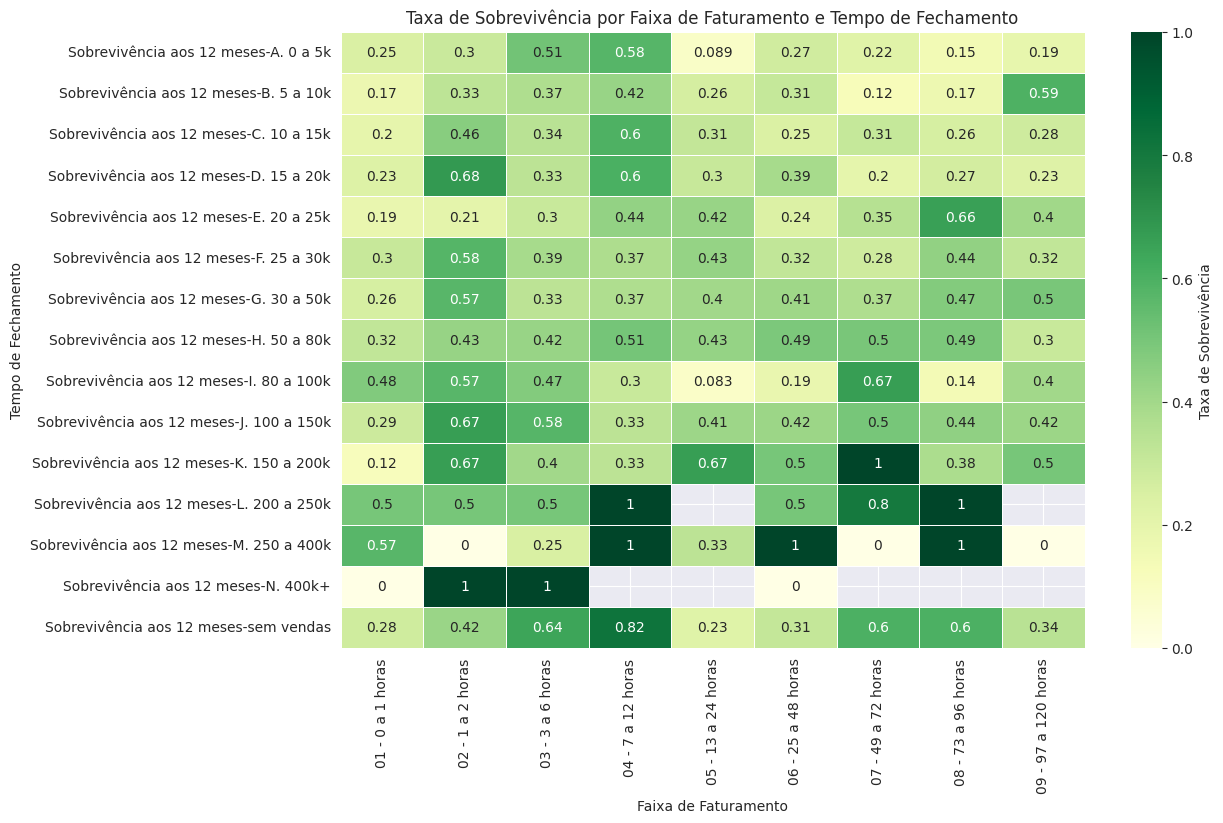

In [ ]:
import pandas as pd
from lifelines import KaplanMeierFitter
import numpy as np

# Importando o CSV diretamente da URL
sheet_url = "https://docs.google.com/spreadsheets/d/1ZudmLpqAdtFCLfhtlgYgfbfeDXMw2S7WBCYw1YnFXHo/export?format=csv"
df = pd.read_csv(sheet_url)


# Converter datas para datetime
df["last_won_date"] = pd.to_datetime(df["last_won_date"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_de_vida_em_dias"] = np.where(
    df["company_lifecycle_stage"] == "customer",
    (df["current_date"] - df["last_won_date"]).dt.days ,
    np.where(
        df["churn_date"].notna(),
        (df["churn_date"] - df["last_won_date"]).dt.days,
        np.nan
    )
)
#df.head(10)

# Remover valores NaN nas variáveis relevantes antes de qualquer outra transformação
df = df.dropna(subset=["ativo", "category_time_for_hours", "tempo_de_vida_em_dias"])

# Mapeando as categorias de tempo para valores numéricos representando a média de horas
category_time_mapping = {
    "01 - 0 a 1 horas": 0.5,
    "02 - 1 a 2 horas": 1.5,
    "03 - 3 a 6 horas": 4.5,
    "04 - 7 a 12 horas": 9.5,
    "05 - 13 a 24 horas": 18.5,
    "06 - 25 a 48 horas": 36.5,
    "07 - 49 a 72 horas": 60.5,
    "08 - 73 a 96 horas": 84.5,
    "09 - 97 a 120 horas": 108.5,
    "10 - Mais de 120 horas": 130
}

# Aplicando a transformação para criar uma coluna numérica de tempo
df['category_time_for_hours_numeric'] = df['category_time_for_hours'].map(category_time_mapping)

# Verificar se há valores NaN após a transformação
df = df.dropna(subset=["category_time_for_hours_numeric"])

# Inicializando o KM
kmf = KaplanMeierFitter()

# Dicionário para armazenar a sobrevivência estimada em 180 dias (6 meses)
survival_matrix = {}

# Para cada combinação de tempo de fechamento e faixa de faturamento
for faturamento in df['faixa_faturamento'].unique():
    for tempo in df['category_time_for_hours'].unique():
        subset = df[(df['faixa_faturamento'] == faturamento) &
                    (df['category_time_for_hours'] == tempo)]

        if len(subset) > 0:
            kmf.fit(subset['tempo_de_vida_em_dias'], event_observed=subset['ativo'])

            # Pegando a sobrevivência aos 180 dias (6 meses)
            prob_12_meses = kmf.predict(360)
            survival_matrix[(faturamento, tempo)] = prob_12_meses

# Convertendo em DataFrame
survival_df = pd.DataFrame.from_dict(survival_matrix, orient='index', columns=['Sobrevivência aos 12 meses'])
survival_df.index = pd.MultiIndex.from_tuples(survival_df.index, names=['Faixa de Faturamento', 'Tempo de Fechamento'])
survival_df = survival_df.unstack(level=0).T

# Exibindo
print(survival_df)
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo o tamanho da figura para o gráfico
plt.figure(figsize=(12, 8))

# Criando o heatmap
sns.heatmap(survival_df, annot=True, cmap="YlGn", cbar_kws={'label': 'Taxa de Sobrevivência'}, linewidths=0.5)

# Adicionando título e labels
plt.title("Taxa de Sobrevivência por Faixa de Faturamento e Tempo de Fechamento")
plt.xlabel("Faixa de Faturamento")
plt.ylabel("Tempo de Fechamento")

# Exibindo o gráfico
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar os dados
sheet_url = "https://docs.google.com/spreadsheets/d/1ZudmLpqAdtFCLfhtlgYgfbfeDXMw2S7WBCYw1YnFXHo/export?format=csv"
df = pd.read_csv(sheet_url)

# Etapa 1: Verificar nomes de colunas e padronizar
category_cols = [col for col in df.columns if "tempo_for_closed_in_second" in col]
print("Colunas de categoria encontradas:", category_cols)

# Etapa 2: Converter valores de texto para numérico (e.g., "0", "1", "Sim", "Não", etc.)
#for col in category_cols:
 #   df[col] = df[col].replace({'Sim': 1, 'Não': 0}).astype(str).str.extract('(\d+)').astype(float)

# Etapa 3: Converter cliente_ativo se necessário
#df['cliente_ativo'] = pd.to_numeric(df['cliente_ativo'], errors='coerce').astype('Int64')

# Etapa 4: Remover linhas com valores ausentes
df_clean = df.dropna(subset=category_cols + ['cliente_ativo'])

# Etapa 5: Calcular correlações
correlations = {
    col: np.corrcoef(df_clean[col], df_clean['cliente_ativo'])[0, 1]
    for col in category_cols
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Categoria', 'Correlação'])
correlation_df = correlation_df.sort_values(by='Correlação', ascending=False)

# Etapa 6: Visualizar
print(correlation_df)


Colunas de categoria encontradas: ['tempo_for_closed_in_second']
                    Categoria  Correlação
0  tempo_for_closed_in_second    0.048876


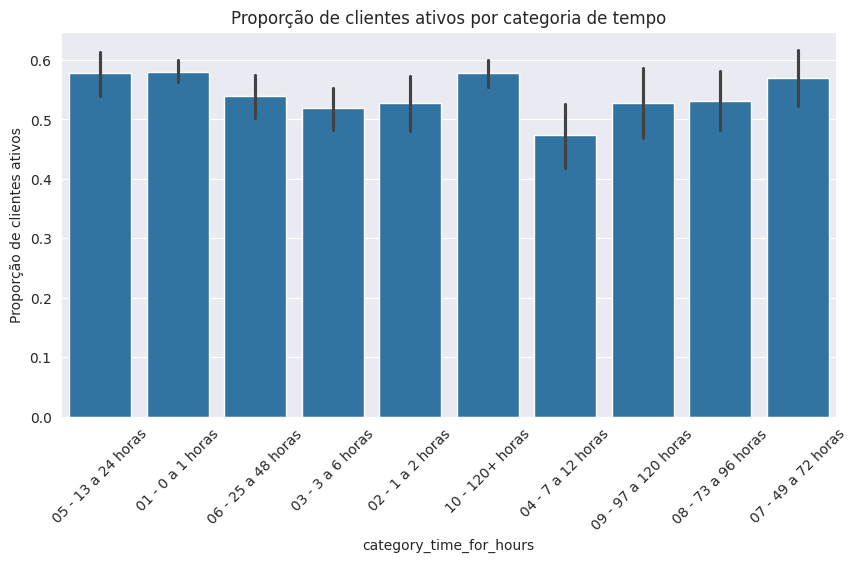

             Categoria  Proporção Ativos
3    04 - 7 a 12 horas          0.473684
2     03 - 3 a 6 horas          0.518470
8  09 - 97 a 120 horas          0.527586
1     02 - 1 a 2 horas          0.527840
7   08 - 73 a 96 horas          0.530831
5   06 - 25 a 48 horas          0.539216
6   07 - 49 a 72 horas          0.570093
4   05 - 13 a 24 horas          0.577677
9      10 - 120+ horas          0.578534
0     01 - 0 a 1 horas          0.580131


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotar a proporção de clientes ativos por categoria
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="category_time_for_hours", y="cliente_ativo")
plt.title("Proporção de clientes ativos por categoria de tempo")
plt.xticks(rotation=45)
plt.ylabel("Proporção de clientes ativos")
plt.show()

churn_rate = df.groupby("category_time_for_hours")["cliente_ativo"].mean().reset_index()
churn_rate.columns = ["Categoria", "Proporção Ativos"]
print(churn_rate.sort_values("Proporção Ativos"))